# Basic neural networks

**NS5007 Human and Artificial Intelligence · lab notebook**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qihongl/NS5007/blob/main/basic_nn.ipynb)

A neural network is a stack of very simple units whose numbers are tuned by data rather than designed by hand. Today we look at one unit, see where a single unit breaks, watch a network learn, and finish with a classifier for handwritten digits.

Work through the three exercises as you go (there is one bonus at the end). Solutions are collapsed at the bottom of the notebook — try each exercise first. Runs top to bottom in a few minutes on a free Colab CPU.


If you are on Colab everything is already installed. The first cell only installs what is missing, so it is safe to run anywhere.

In [1]:
import importlib.util
import subprocess
import sys

for mod_name, pip_name in [("numpy", "numpy"), ("matplotlib", "matplotlib"),
                           ("sklearn", "scikit-learn"), ("torch", "torch")]:
    if importlib.util.find_spec(mod_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from sklearn.datasets import make_blobs, make_moons, load_digits
from sklearn.model_selection import train_test_split

np.random.seed(7)
torch.manual_seed(7)

plt.rcParams.update({
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 100,
})

print("torch", torch.__version__)

torch 2.12.0


## 1. A single neuron

An artificial neuron takes numbers in, computes a weighted sum plus a bias, and passes the result through a fixed nonlinearity:

```
score z = w·x + b          activation a = f(z)
```

The weights `w` and bias `b` are the numbers that get learned. Everything else in a neural network is many of these units wired together.

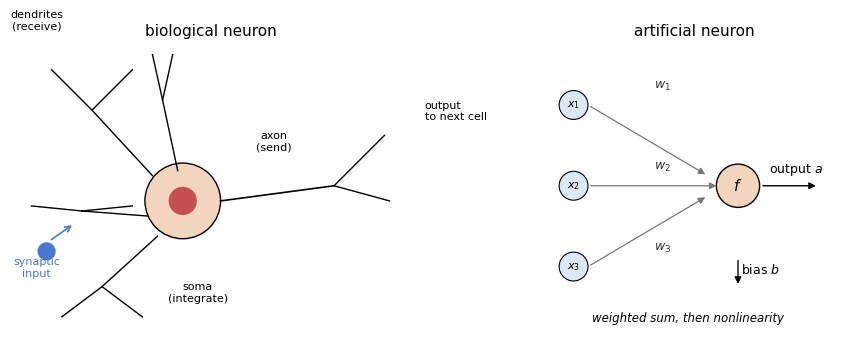

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
for ax in axes:
    ax.set_aspect("equal")
    ax.axis("off")

# ---- biological
ax = axes[0]
ax.set_title("biological neuron", fontsize=11, pad=4)
ax.add_patch(plt.Circle((0.42, 0.5), 0.075, fc="#f2d5bd", ec="k", lw=1))
ax.add_patch(plt.Circle((0.42, 0.5), 0.028, fc="#c44e52", ec="none"))
dendrites = [((0.36, 0.55), (0.24, 0.68), (0.16, 0.76)),
             ((0.35, 0.47), (0.22, 0.48), (0.12, 0.49)),
             ((0.37, 0.43), (0.26, 0.33), (0.18, 0.27)),
             ((0.41, 0.56), (0.38, 0.70), (0.36, 0.79))]
for p0, p1, p2 in dendrites:
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color="k", lw=1)
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="k", lw=1)
    ax.plot([p1[0], 2 * p1[0] - p2[0]], [p1[1], p2[1]], color="k", lw=1)
ax.plot([0.495, 0.72], [0.5, 0.53], color="k", lw=1.2)          # axon
ax.plot([0.72, 0.82], [0.53, 0.63], color="k", lw=1)             # terminals
ax.plot([0.72, 0.83], [0.53, 0.50], color="k", lw=1)
ax.add_patch(plt.Circle((0.15, 0.40), 0.018, fc="#4878CF", ec="none"))
ax.annotate("", xy=(0.205, 0.455), xytext=(0.155, 0.42),
            arrowprops=dict(arrowstyle="->", color="#4878CF", lw=1.2))
ax.text(0.13, 0.35, "synaptic\ninput", fontsize=8, ha="center", color="#4878CF")
ax.text(0.13, 0.84, "dendrites\n(receive)", fontsize=8, ha="center")
ax.text(0.45, 0.30, "soma\n(integrate)", fontsize=8, ha="center")
ax.text(0.60, 0.60, "axon\n(send)", fontsize=8, ha="center")
ax.text(0.90, 0.66, "output\nto next cell", fontsize=8, ha="left")

# ---- artificial
ax = axes[1]
ax.set_title("artificial neuron", fontsize=11, pad=4)
for yi, lb, wl, wx in [(0.78, "$x_1$", "$w_1$", 0.36),
                       (0.50, "$x_2$", "$w_2$", 0.36),
                       (0.22, "$x_3$", "$w_3$", 0.36)]:
    ax.add_patch(plt.Circle((0.08, yi), 0.05, fc="#dbe9f6", ec="k", lw=0.8))
    ax.text(0.08, yi, lb, ha="center", va="center", fontsize=8)
    tip = (0.585, 0.50) if abs(yi - 0.5) < 0.01 else ((0.545, 0.535) if yi > 0.5 else (0.545, 0.465))
    ax.annotate("", xy=tip, xytext=(0.13, yi),
                arrowprops=dict(arrowstyle="-|>", color="#777777", lw=0.9))
    ax.text(wx, yi + (0.055 if yi >= 0.5 else 0.055), wl, fontsize=9, color="#333333")
ax.add_patch(plt.Circle((0.65, 0.5), 0.075, fc="#f2d5bd", ec="k"))
ax.text(0.65, 0.5, "$f$", ha="center", va="center", fontsize=11)
ax.annotate("", xy=(0.65, 0.15), xytext=(0.65, 0.25),
            arrowprops=dict(arrowstyle="-|>", color="k", lw=1))
ax.text(0.66, 0.195, "bias $b$", fontsize=9)
ax.annotate("", xy=(0.93, 0.5), xytext=(0.727, 0.5),
            arrowprops=dict(arrowstyle="-|>", color="k", lw=1))
ax.text(0.85, 0.545, "output $a$", fontsize=9, ha="center")
ax.text(0.475, 0.03, "weighted sum, then nonlinearity", fontsize=8.5, ha="center", style="italic")

fig.tight_layout()
plt.show()

Common choices for `f`:

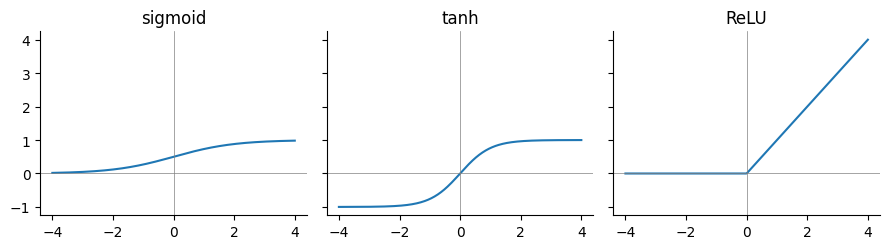

In [3]:
x = np.linspace(-4, 4, 300)
fig, axes = plt.subplots(1, 3, figsize=(9, 2.6), sharey=True)
axes[0].plot(x, 1 / (1 + np.exp(-x)));       axes[0].set_title("sigmoid")
axes[1].plot(x, np.tanh(x));                 axes[1].set_title("tanh")
axes[2].plot(x, np.maximum(x, 0));           axes[2].set_title("ReLU")
for ax in axes:
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
fig.tight_layout()
plt.show()

They all just squash or clip. We will use ReLU for hidden units; the output layer's choice comes later.

Now some data. Two clusters in 2D, blue and red. A single neuron computes one score per point; we will treat score > 0 as "red" and score ≤ 0 as "blue". The boundary score = 0 is always a straight line, no matter how you set the weights.

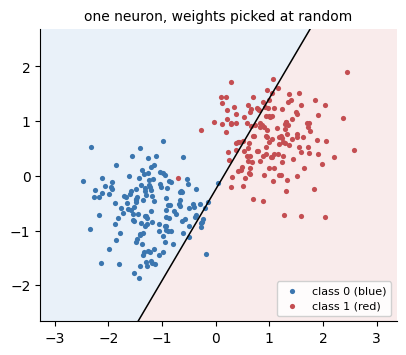

In [4]:
# the two clusters used throughout sections 1 and 3
X, y = make_blobs(n_samples=300, centers=[(-1.2, -0.6), (1.0, 0.8)],
                  cluster_std=0.55, random_state=7)
y = y.astype(np.float32)
Xt = torch.tensor(X, dtype=torch.float32)
yt = torch.tensor(y)


def scatter_pts(ax, X, y):
    ax.scatter(*X[y == 0].T, s=14, c="#3b76af", linewidths=0, label="class 0 (blue)")
    ax.scatter(*X[y == 1].T, s=14, c="#c44e52", linewidths=0, label="class 1 (red)")


def draw_region(ax, score_fn, X, pad=0.8, res=240):
    """Shade score>0 red / score<0 blue and draw the score=0 line. score_fn takes an
    (N,2) torch tensor and returns an (N,) score."""
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    gx, gy = np.meshgrid(np.linspace(x_min, x_max, res), np.linspace(y_min, y_max, res))
    grid = torch.tensor(np.c_[gx.ravel(), gy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        z = score_fn(grid)
    z = np.asarray(z, dtype=float).reshape(gx.shape)
    ax.contourf(gx, gy, np.where(z > 0, 1.0, 0.0),
                levels=[-0.5, 0.5, 1.5], colors=["#dbe9f6", "#f6dede"], alpha=0.6)
    ax.contour(gx, gy, z, levels=[0], colors="k", linewidths=1.1)


w = torch.tensor([2.0, -1.2])
b = torch.tensor([-0.3])

fig, ax = plt.subplots(figsize=(4.6, 3.8))
draw_region(ax, lambda t: t @ w + b, X)
scatter_pts(ax, X, y)
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
ax.set_title("one neuron, weights picked at random", fontsize=10)
plt.show()

**Exercise 1.** Change `w` and `b` in the cell above until the black line separates blue from red (as close to zero mistakes as you can).

Two facts to help you aim: the line is perpendicular to `w`, and increasing `b` slides the line away from the origin in the direction *opposite* to `w` — its distance from the origin is |b|/‖w‖. Before each run, predict which way your change will move it.

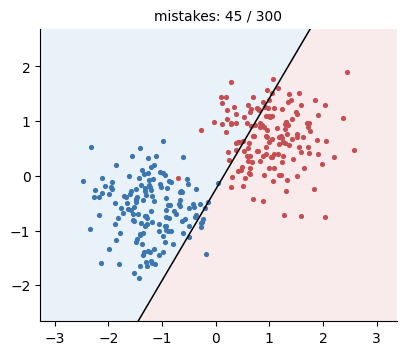

In [5]:
# --- Exercise 1: edit w and b, then rerun this cell as many times as you like ---
w = torch.tensor([2.0, -1.2])   # <- edit me
b = torch.tensor([-0.3])        # <- edit me

fig, ax = plt.subplots(figsize=(4.6, 3.8))
draw_region(ax, lambda t: t @ w + b, X)
scatter_pts(ax, X, y)
errors = ((X @ w.numpy() + b.numpy() > 0) != (y == 1)).sum()
ax.set_title(f"mistakes: {int(errors)} / {len(y)}", fontsize=10)
plt.show()

Down to a couple of mistakes? That is the floor here — the two clusters touch, so no straight line gets below ~1 error. Hold that thought: this cluster pair was easy, and next we meet a case where no amount of tuning helps.

## 2. Where a single neuron fails

Two half-moons, nested.

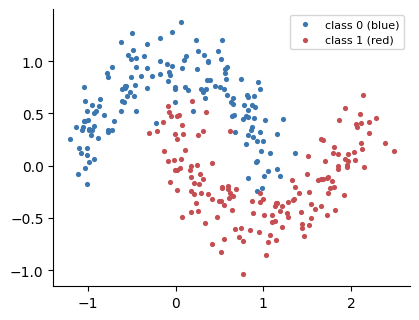

In [6]:
Xm, ym = make_moons(n_samples=300, noise=0.18, random_state=7)

fig, ax = plt.subplots(figsize=(4.6, 3.6))
scatter_pts(ax, Xm, ym)
ax.legend(loc="upper right", fontsize=8)
plt.show()

No straight line can separate these. Rather than take my word for it, let a computer try: below we sweep all 59,400 candidate lines on a grid (60 directions × 30 scales × 33 offsets) and keep the best.

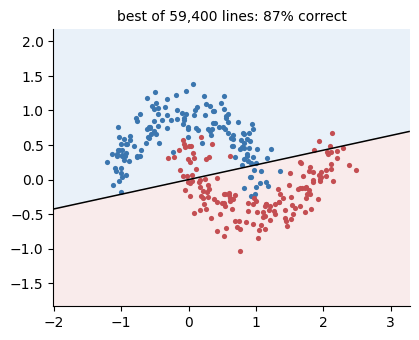

In [7]:
best_acc, best_w, best_b = 0.0, None, None
offsets = np.linspace(-4, 4, 33)
n_angles, n_scales = 60, 30
for k in range(n_angles):
    theta = 2 * np.pi * k / n_angles
    wv = np.array([np.cos(theta), np.sin(theta)])
    proj = Xm @ wv
    for s in np.linspace(0.5, 6, n_scales):
        p = s * proj
        accs = (((p[None, :] + offsets[:, None]) > 0) == ym[None, :]).mean(axis=1)
        i = accs.argmax()
        if accs[i] > best_acc:
            best_acc = float(accs[i])
            best_w, best_b = wv * s, s * float(offsets[i])

fig, ax = plt.subplots(figsize=(4.6, 3.6))
draw_region(ax, lambda t: t @ torch.tensor(best_w, dtype=torch.float32) + best_b, Xm)
scatter_pts(ax, Xm, ym)
ax.set_title(f"best of {n_angles * n_scales * len(offsets):,} lines: "
             f"{best_acc:.0%} correct", fontsize=10)
plt.show()

The best possible straight line still misclassifies about 1 point in 8, and the errors sit along the crescent tips where the moons interlock. This is the limitation that made single-layer models look like a dead end in the 1960s. The fix — stacking neurons — needs one more ingredient first: a way to *learn* the numbers instead of hand-picking them.

## 3. Learning the numbers

Learning = choosing `w` and `b` to make a **loss** small. For two-class problems the standard loss is cross-entropy: small when the network's score agrees with the label, large when it disagrees. This is the same loss you met as logistic regression in an earlier lab — a single neuron trained with it *is* logistic regression.

Gradient descent then works exactly like the name says: measure the slope of the loss with respect to each number, step a little downhill, repeat. One wrinkle from the picture below: how far you step (the **learning rate**) matters as much as the direction.

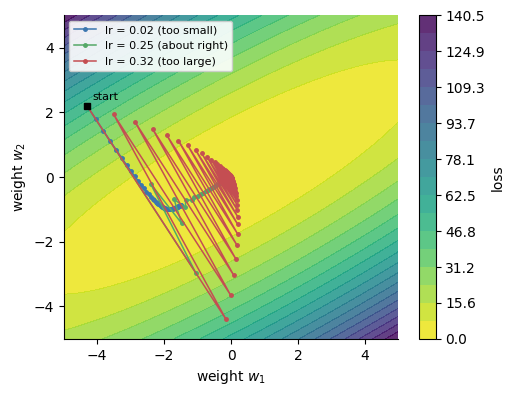

In [8]:
# a stylized loss surface: an elongated bowl, the shape real losses have
# near their minimum. Two weights on the axes, loss on the height.
theta = np.deg2rad(30)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
A = R @ np.diag([0.35, 6.0]) @ R.T          # steep across the valley, gentle along it


def bowl(w):
    return 0.5 * w @ A @ w


def gd_path(lr, n_steps=60, start=np.array([-4.3, 2.2])):
    path = [start.copy()]
    w = start.copy().astype(float)
    for _ in range(n_steps):
        w = w - lr * (A @ w)                # one gradient-descent step
        path.append(w.copy())
    return np.array(path)


g = np.linspace(-5, 5, 200)
W1, W2 = np.meshgrid(g, g)
L = np.array([[bowl(np.array([a, b])) for a, b in zip(ra, rb)]
              for ra, rb in zip(W1, W2)])

fig, ax = plt.subplots(figsize=(5.4, 4.2))
cs = ax.contourf(W1, W2, L, levels=np.linspace(0, L.max(), 19),
                 cmap="viridis_r", alpha=0.85)
fig.colorbar(cs, ax=ax, label="loss")
for lr, col, lab in [(0.02, "#3b76af", "lr = 0.02 (too small)"),
                     (0.25, "#55a868", "lr = 0.25 (about right)"),
                     (0.32, "#c44e52", "lr = 0.32 (too large)")]:
    P = gd_path(lr)
    ax.plot(P[:, 0], P[:, 1], "-o", color=col, ms=2.5, lw=1.1, label=lab)
ax.plot(*gd_path(0.3)[0], marker="s", color="k", ms=5)
ax.annotate("start", (gd_path(0.3)[0][0] + 0.15, gd_path(0.3)[0][1] + 0.2), fontsize=8)
ax.set_xlabel("weight $w_1$"); ax.set_ylabel("weight $w_2$")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
plt.show()

The green path steps downhill and settles in the valley. The blue one makes such timid steps that after 60 rounds it is still halfway down the slope. The red one overshoots the valley floor and bounces across it for dozens of steps before the oscillation finally damps.

(A stylized bowl, but real loss surfaces have exactly this shape near their minimum.)

How are the slopes computed? Autograd. Three lines:

In [9]:
w = torch.tensor(3.0, requires_grad=True)   # track this number
z = w ** 2                                  # some function of it
z.backward()                                # compute dz/dw through the graph
print(w.grad)                               # expect 2*w = 6

tensor(6.)


`backward()` differentiates the whole computation graph at once, and that machinery keeps working no matter how many layers we stack — this is what people call backpropagation, and it is handled for us. Our job is only to wire the pieces together:

1. get predictions: `logits = model(X)`
2. measure how wrong: `loss = loss_fn(logits, y)`
3. clear stale gradients: `optimizer.zero_grad()`
4. compute new gradients: `loss.backward()`
5. take one downhill step: `optimizer.step()`

**Exercise 2.** The loop below is the recipe from above with three lines replaced by placeholders (steps 1, 3, 5). Replace them and run until the final loss drops below 0.1.

Diagnosis guide while you work: a loss pinned at exactly 0.693 — that is ln 2, the loss of pure guessing — means the `logits` line is still a placeholder; a loss that never decreases means `optimizer.step()` is missing; a loss that decreases erratically means `optimizer.zero_grad()` is missing.

In [10]:
# --- Exercise 2: replace the three placeholder lines, then run ---
torch.manual_seed(7)
model = nn.Linear(2, 1)                            # one neuron: w (2 numbers) + b
optimizer = optim.SGD(model.parameters(), lr=0.5)  # plain gradient descent
loss_fn = nn.BCEWithLogitsLoss()                   # cross-entropy on raw scores

losses = []
for epoch in range(60):
    logits = 0 * model(Xt).squeeze(-1)   # TODO 1: placeholder (always zero) — replace with the model's real scores

    loss = loss_fn(logits, yt)
    losses.append(loss.item())

    pass                            # TODO 2: replace — erase gradients left over from last round

    loss.backward()                 # gradients for every parameter
    pass                            # TODO 3: replace — the actual downhill step

print(f"final loss: {losses[-1]:.3f}   (started at {losses[0]:.3f})")

final loss: 0.693   (started at 0.693)


In [11]:
# --- run this after Exercise 2 works: does the neuron actually classify well? ---
with torch.no_grad():
    acc = ((model(Xt).squeeze(-1) > 0) == yt.bool()).float().mean().item()
print(f"training accuracy: {acc:.1%}")

training accuracy: 23.7%


The same five lines train *any* network, so let me wrap them in one function and stop repeating them. It also records copies of the parameters at chosen epochs so we can watch the boundary move.

In [12]:
def train_model(model, X, y, loss_fn, lr, epochs, snapshot_epochs=(), seed=7):
    """Full-batch gradient descent. Returns (losses, {epoch: state_dict copy})."""
    torch.manual_seed(seed)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    losses, snaps = [], {}
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(X)
        if out.shape[-1] == 1:      # binary case: (N,1) -> (N,)
            out = out.squeeze(-1)
        loss = loss_fn(out, y)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
        if epoch in snapshot_epochs:
            snaps[epoch] = {k: v.clone() for k, v in model.state_dict().items()}
    return losses, snaps


torch.manual_seed(7)   # seed BEFORE construction: train_model seeds the training loop,
                       # but model initialization happens here at the call site
losses2, snaps1 = train_model(nn.Linear(2, 1), Xt, yt.squeeze(-1),
                              nn.BCEWithLogitsLoss(), lr=0.5, epochs=60,
                              snapshot_epochs=(0, 3, 10, 30, 59))
print(f"reference run final loss: {losses2[-1]:.3f}  — should match your Exercise 2")

reference run final loss: 0.059  — should match your Exercise 2


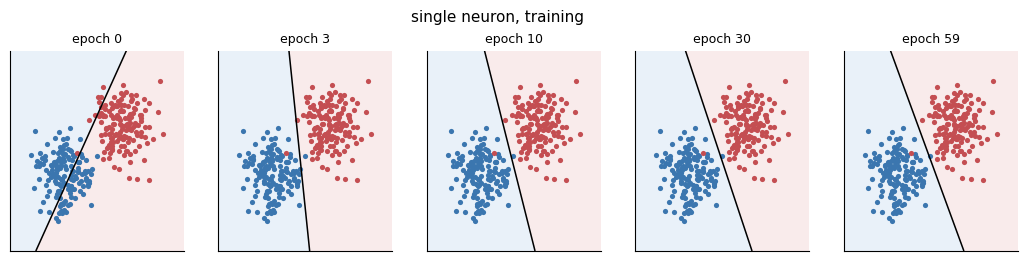

In [13]:
# the straight line rotating into place during training
fig, axes = plt.subplots(1, 5, figsize=(13, 2.6))
for ax, (ep, sd) in zip(axes, snaps1.items()):
    model.load_state_dict(sd)
    draw_region(ax, lambda t: model(t).squeeze(-1), X)
    scatter_pts(ax, X, y)
    ax.set_title(f"epoch {ep}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("single neuron, training", y=1.04, fontsize=11)
plt.show()

**Exercise 3.** The learning rate is the knob people break most often. The cell below trains the same neuron with three values. Run it, then fill in the table underneath.

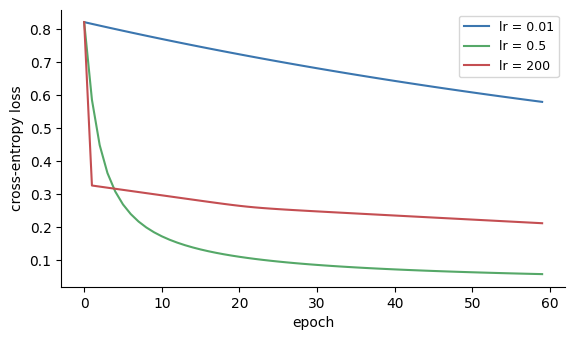

In [14]:
# --- Exercise 3: run, then describe what each curve does ---
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for lr, col in [(0.01, "#3b76af"), (0.5, "#55a868"), (200, "#c44e52")]:
    torch.manual_seed(7)     # same init for all three curves: only the step size differs
    lrs, _ = train_model(nn.Linear(2, 1), Xt, yt.squeeze(-1),
                         nn.BCEWithLogitsLoss(), lr=lr, epochs=60)
    ax.plot(lrs, color=col, lw=1.5, label=f"lr = {lr}")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss")
ax.legend(fontsize=9)
plt.show()


Fill in one short phrase per row:

| lr | what the loss curve does | why |
|------|--------------------------|-----|
| 0.01 | ................................ | |
| 0.5 | ................................ | |
| 200 | ................................ | |

## 4. Depth fixes the moons

Now we can go back and beat the 87% ceiling. The network below hides 16 neurons between input and output. Count its parameters — each is a number learning will adjust.

In [15]:
moons_net = nn.Sequential(
    nn.Linear(2, 16),      # 16 neurons, each with 2 weights + 1 bias
    nn.ReLU(),             # no parameters, just the fold
    nn.Linear(16, 1),      # reads all 16, outputs one score
)
print(sum(p.numel() for p in moons_net.parameters()), "parameters")

65 parameters


Each hidden neuron draws its own straight line; ReLU keeps one side and zeros the other, which creases the plane like folded paper. The output neuron runs along the folded surface, so its "straight" boundary looks curved to us. Train and see both views:

In [16]:
Xmt = torch.tensor(Xm, dtype=torch.float32)
ymt = torch.tensor(ym.astype(np.float32))

losses_m, snaps_m = train_model(moons_net, Xmt, ymt.squeeze(-1),
                                nn.BCEWithLogitsLoss(), lr=0.5, epochs=1200,
                                snapshot_epochs=(0, 50, 300, 1199))
with torch.no_grad():
    acc_m = ((moons_net(Xmt).squeeze(-1) > 0) == ymt.bool()).float().mean().item()
print(f"training accuracy: {acc_m:.1%}  (best straight line: {best_acc:.0%})")

training accuracy: 97.7%  (best straight line: 87%)


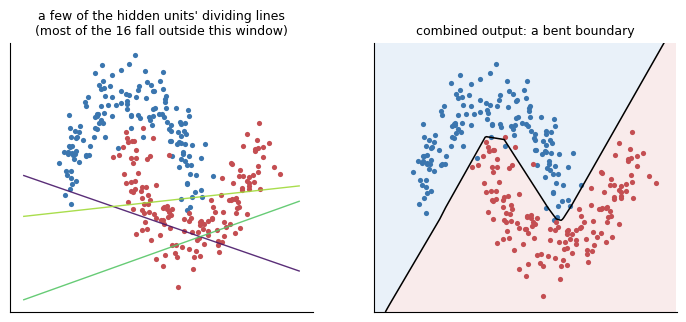

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.5))
gx, gy = np.meshgrid(np.linspace(-1.8, 2.8, 240), np.linspace(-1.2, 1.6, 240))
grid = torch.tensor(np.c_[gx.ravel(), gy.ravel()], dtype=torch.float32)

# left: every hidden unit's own line, faint
axes[0].set_title("a few of the hidden units' dividing lines\n(most of the 16 fall outside this window)", fontsize=9)
cols = plt.cm.viridis(np.linspace(0, 0.92, 16))
W0 = snaps_m[1199]["0.weight"].numpy(); b0 = snaps_m[1199]["0.bias"].numpy()
xx = np.array([-1.8, 2.8])
for i in range(16):
    if abs(W0[i, 1]) > 1e-6:
        yy = (-W0[i, 0] * xx - b0[i]) / W0[i, 1]
        keep = (yy > -1.2) & (yy < 1.6)
        axes[0].plot(xx[keep], yy[keep], lw=1, alpha=0.9, color=cols[i])
scatter_pts(axes[0], Xm, ym)

# right: the combined boundary
with torch.no_grad():
    z = moons_net(grid).squeeze(-1).numpy().reshape(gx.shape)
axes[1].contourf(gx, gy, np.where(z > 0, 1, 0),
                 levels=[-0.5, 0.5, 1.5], colors=["#dbe9f6", "#f6dede"], alpha=0.6)
axes[1].contour(gx, gy, z, levels=[0], colors="k", linewidths=1.1)
axes[1].set_title("combined output: a bent boundary", fontsize=9)
scatter_pts(axes[1], Xm, ym)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

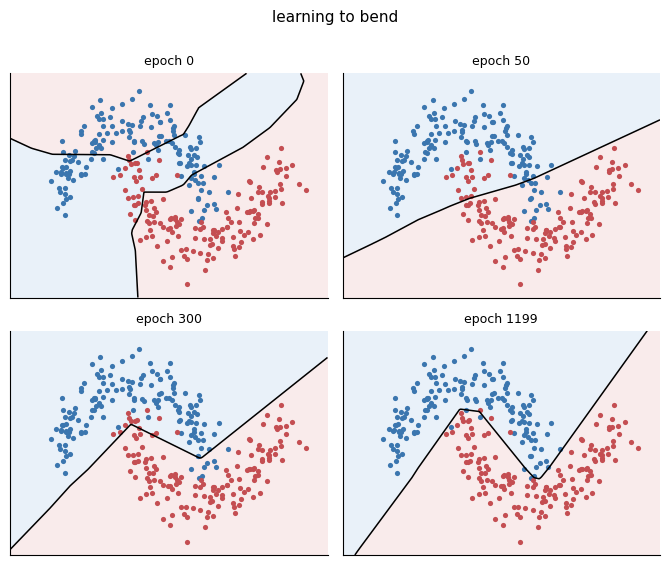

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(6.8, 5.6))
for ax, ep in zip(axes.ravel(), snaps_m):
    moons_net.load_state_dict(snaps_m[ep])
    with torch.no_grad():
        z = moons_net(grid).squeeze(-1).numpy().reshape(gx.shape)
    ax.contourf(gx, gy, np.where(z > 0, 1, 0),
                levels=[-0.5, 0.5, 1.5], colors=["#dbe9f6", "#f6dede"], alpha=0.6)
    ax.contour(gx, gy, z, levels=[0], colors="k", linewidths=1.1)
    scatter_pts(ax, Xm, ym)
    ax.set_title(f"epoch {ep}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("learning to bend", y=1.0, fontsize=11)
fig.tight_layout()
plt.show()

## 5. Real-ish data: handwritten digits

Same recipe, one change at a time. The data: 1,797 scanned digits, each an 8×8 grayscale image, 10 classes.

(1797, 64) — flattened to 64 input features


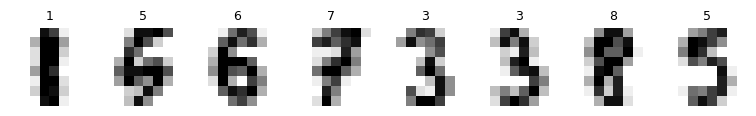

In [19]:
digits, labels = load_digits(return_X_y=True)
print(digits.shape, "— flattened to", digits.shape[1], "input features")

Xtr, Xte, ytr, yte = train_test_split(digits, labels, test_size=0.25,
                                      random_state=7, stratify=labels)
Xtr, Xte = Xtr / 16.0, Xte / 16.0   # pixel values 0-15 -> 0-1

fig, axes = plt.subplots(1, 8, figsize=(9.5, 1.9))
for ax, img, lab in zip(axes, Xte[:8], yte[:8]):
    ax.imshow(img.reshape(8, 8), cmap="gray_r")
    ax.set_title(str(lab), fontsize=9)
    ax.axis("off")
plt.show()

Three things change for 10 classes: the output layer has 10 neurons (one score per digit), the loss becomes cross-entropy over those 10 scores, and labels must be integers (`dtype=long`) — mismatched label types are the most common error here. Train/test split is new too: we grade on digits the network never saw.

In [20]:
torch.manual_seed(7)
digit_net = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 10))
loss_d, _ = train_model(digit_net,
                        torch.tensor(Xtr, dtype=torch.float32),
                        torch.tensor(ytr, dtype=torch.long),
                        nn.CrossEntropyLoss(), lr=0.5, epochs=300)
with torch.no_grad():
    pred = digit_net(torch.tensor(Xte, dtype=torch.float32)).argmax(1).numpy()
print(f"test accuracy: {(pred == yte).mean():.1%}")

test accuracy: 97.3%


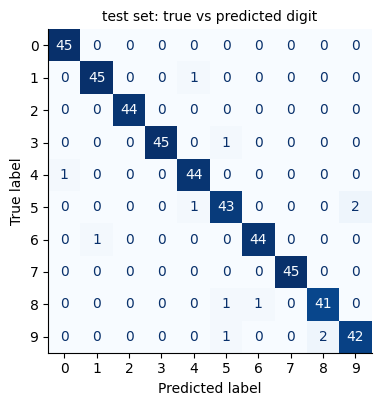

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay(confusion_matrix(yte, pred)).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title("test set: true vs predicted digit", fontsize=10)
plt.show()

12 of 450 test digits wrong



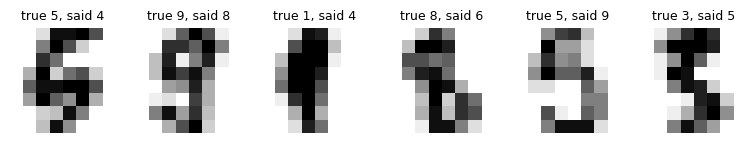

In [22]:
errors = np.where(pred != yte)[0]
print(f"{len(errors)} of {len(yte)} test digits wrong\n")

fig, axes = plt.subplots(1, 6, figsize=(9.5, 2.0))
for ax, i in zip(axes, errors[:6]):
    ax.imshow(Xte[i].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"true {yte[i]}, said {pred[i]}", fontsize=9)
    ax.axis("off")
plt.show()

**Bonus.** If you finish the exercises early, any of these:

- Push test accuracy to 98% or above.
- Keep accuracy at 97%+ with fewer than 1,500 parameters.
- Go back to the moons and raise `noise` until the network struggles too — where does depth stop helping?

The cell below is a copy of the training call, ready to modify. Every cell here seeds before building its model, so a fresh `Run all` reproduces all numbers exactly. One caveat: different architectures necessarily get different random initializations (they have different shapes), so for close calls try a second seed before concluding anything.

In [23]:
# --- Bonus playground ---
torch.manual_seed(7)
net = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 10))
loss_b, _ = train_model(net,
                        torch.tensor(Xtr, dtype=torch.float32),
                        torch.tensor(ytr, dtype=torch.long),
                        nn.CrossEntropyLoss(), lr=0.5, epochs=300)
with torch.no_grad():
    acc_b = (net(torch.tensor(Xte, dtype=torch.float32)).argmax(1).numpy() == yte).mean()
print(f"params: {sum(p.numel() for p in net.parameters())}   test accuracy: {acc_b:.1%}")

params: 9610   test accuracy: 97.3%


## Wrap-up

One neuron draws a line. A hidden layer creases the plane along many lines, and the output layer reads the folded result — which is how a stack of simple pieces ends up drawing curves. Training is nothing more than the five-step loop from Exercise 2, wherever those numbers live.

| neural networks | rough neuroscience analogue |
|---|---|
| weight | synaptic strength |
| bias | intrinsic excitability |
| activation function | input–output (firing-rate) nonlinearity |
| hidden layer | (very loose) hierarchical processing stages |
| loss | task error driving adaptation |
| learning rate | plasticity step size |
| training on data | experience-dependent plasticity |

The analogy is loose — today's units are far cruder than real neurons — but close enough that the two fields keep borrowing from each other. Coming up: how to choose and regularize models like these; later, what happens when the same units get wired into convolutional layers for images.

### References & credits
- Data: scikit-learn (`make_blobs`, `make_moons`, `load_digits`); framework: [PyTorch](https://pytorch.org).
- On the 1960s single-layer pessimism: Minsky & Papert, *Perceptrons* (1969).

## Solutions

Each one folds open. Compare with your own attempt — different numbers can be just as correct.

<details><summary><b>Exercise 1</b></summary>

Any `w` pointing from blue toward red works, with `b` set so the line passes between the clusters. For our data the vector from blue center (−1.2, −0.6) to red center (1.0, 0.8) is roughly (2.2, 1.4), so:

```python
w = torch.tensor([1.69, 1.07])
b = torch.tensor([0.10])     # 2 mistakes / 300 (no line beats ~1 here: the clusters touch);
                             # any positive multiple of this pair works too
```

Scaling both `w` and `b` by the same factor moves nothing — the boundary only depends on their ratio. That is a hint about why learning cares more about the *direction* of weights than their size.

</details>

<details><summary><b>Exercise 2</b></summary>

```python
torch.manual_seed(7)
model = nn.Linear(2, 1)
optimizer = optim.SGD(model.parameters(), lr=0.5)
loss_fn = nn.BCEWithLogitsLoss()

losses = []
for epoch in range(60):
    logits = model(Xt).squeeze(-1)      # replaces the zeros placeholder

    loss = loss_fn(logits, yt)
    losses.append(loss.item())

    optimizer.zero_grad()               # replaces the first pass

    loss.backward()
    optimizer.step()                    # replaces the second pass

print(f"final loss: {losses[-1]:.3f}")  # 0.06
```

Final loss should be about 0.06 and accuracy 99%+. The `squeeze(-1)` matters: `model(Xt)` has shape (300, 1) and the loss wants (300,). If the loss stays pinned at 0.693, a placeholder is still in place — most often the `logits` line.

</details>

<details><summary><b>Exercise 3</b></summary>

| lr | what the loss curve does | why |
|------|--------------------------|-----|
| 0.01 | crawls: still high at epoch 60 | steps too small to travel |
| 0.5 | smooth, fast drop, flattens out | step size matched to the valley |
| 200 | drops fast, then hovers far above where 0.5 got to | every step overshoots the minimum |

Same recipe, same data — the only difference is how far each step travels. There is no universal right value, which is why a later lab is about tuning and model selection.

</details>

<details><summary><b>Bonus</b></summary>

All three are reachable with the same loop:

```python
# 98%+: a wider hidden layer
net = nn.Sequential(nn.Linear(64, 256), nn.ReLU(), nn.Linear(256, 10))
train_model(net, torch.tensor(Xtr, dtype=torch.float32),
            torch.tensor(ytr, dtype=torch.long),
            nn.CrossEntropyLoss(), lr=0.6, epochs=400)      # ~98.4%

# 97%+ under 1,500 parameters: a narrow layer
net = nn.Sequential(nn.Linear(64, 16), nn.ReLU(), nn.Linear(16, 10))
# lr=0.6, epochs=400  ->  1,210 parameters, ~98.0%
```

For the moons: by `noise=0.35` the classes overlap so heavily that even this network drops to ≈88% training accuracy (noise=0.30 still gives ≈92%). No architecture recovers information the data does not contain — a first taste of why the *data* limits a model as much as its size does.

</details>